<a href="https://colab.research.google.com/github/michaeljvargas/Tesla-stock-EV-analysis/blob/main/notebooks/Tesla_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tesla Stock Prediction & EV Market Analysis

## Group Members
- Michael Vargas
- Eli Kaplan
- Nhan Nguyen

## Project Summary
This project analyzes Tesla’s historical stock performance and builds machine learning models to predict Tesla’s next-day closing stock price. A second EV market dataset is included to provide industry context, showing how broader electric vehicle adoption trends may support the business story behind Tesla’s market position.

## Business Goal
The goal is to help investors and analysts better understand short-term stock movement patterns by using historical Tesla stock data, technical indicators, and market context from the global EV industry.

--------------------------------------------------------------------

# Business Problem & Context

## Organization
Tesla, Inc. is one of the most visible companies in the electric vehicle market and has historically attracted strong investor attention due to its growth, volatility, and leadership position in EV innovation.

## Business Challenge
Tesla’s stock is highly volatile, which makes short-term forecasting difficult. Investors and analysts need better tools to identify patterns in Tesla’s trading behavior and estimate next-day stock prices more effectively.

## Why This Matters
If investors can better understand short-term price movement, they can make more informed decisions about timing, risk, and portfolio strategy. From a business analytics perspective, this project also shows how machine learning can support financial forecasting and strategic interpretation of market behavior.

## Industry & Market Context
Tesla operates in a rapidly changing EV market shaped by rising electrified vehicle adoption, changing policy support, and growing competition from firms such as BYD and traditional automakers. This broader market context matters because Tesla’s performance is tied not only to company-specific activity but also to overall EV demand and competitive pressure.

-------------------------------------------------------------

# Data Sources & References

## Datasets Used

### 1. Tesla Historical Stock Data
- Source used in project: Kaggle Tesla stock dataset
- Original source: Yahoo Finance historical TSLA data
- Contents: Daily stock data including Date, Open, High, Low, Close, Volume, moving averages, volatility, returns, and time-based features

### 2. Global EV Market Data
- Source used in project: Kaggle EV market dataset
- Original source: International Energy Agency, Global EV Data Explorer / Global EV Outlook
- Contents: Historical EV sales, stock, and market share by country, year, powertrain type, and metric

## Business Context References
1. International Energy Agency, Global EV Outlook / Global EV Data Explorer
2. Reuters reporting on Tesla’s competitive and market environment

-------------------------------------------------------------------------

# Data Acquisition & Loading

The datasets used in this project were obtained from Kaggle and uploaded into the Google Colab environment for analysis.

The Tesla stock dataset is originally sourced from Yahoo Finance and contains daily trading data from 2010 to 2025, including price, volume, and pre-calculated technical indicators such as moving averages and volatility.

The EV market dataset is based on data from the International Energy Agency (IEA) and provides global electric vehicle sales, stock, and market share information across different regions and years.

Both datasets were loaded into Python using the pandas library. No additional preprocessing steps such as API calls or file extraction were required, as the datasets were already in clean CSV format. After loading, the structure and data types of each dataset were inspected to ensure readiness for analysis.

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

# Load datasets
tesla_df = pd.read_csv("/content/tesla_stock.csv")
ev_df = pd.read_csv("/content/ev_market.csv")

print("Tesla dataset shape:", tesla_df.shape)
print("EV dataset shape:", ev_df.shape)

Tesla dataset shape: (3902, 18)
EV dataset shape: (3798, 8)


-----------------------------------------------


# Data Exploration (EDA)

This section explores the Tesla stock dataset and EV market dataset to understand data structure, trends, and relationships between variables. The goal is to identify patterns, detect potential issues, and prepare the data for modeling.

## Initial Data Inspection

The Tesla dataset contains over 3,900 observations and includes price, volume, and engineered features such as moving averages and volatility. The dataset appears clean with consistent numeric formats.

The EV dataset is structured differently, using a long format with categorical fields such as region, parameter, and powertrain. This dataset will be used primarily for understanding broader industry trends.

In [58]:
# First look at data
tesla_df.head()


,Date,Open,High,Low,Close,Volume,Daily_Return,Price_Range,Price_Change,Price_Change_Percent,MA_7,MA_30,MA_90,Volatility_7d,Year,Month,Day_of_Week,Quarter
0,2010-06-29,1.27,1.67,1.17,1.59,281494500,NaN,0.50,0.32,25.20,NaN,NaN,NaN,NaN,2010,6,Tuesday,2
1,2010-06-30,1.72,2.03,1.55,1.59,257806500,0.0000,0.48,-0.13,-7.56,NaN,NaN,NaN,NaN,2010,6,Wednesday,2
2,2010-07-01,1.67,1.73,1.35,1.46,123282000,-0.0818,0.38,-0.21,-12.57,NaN,NaN,NaN,NaN,2010,7,Thursday,3
3,2010-07-02,1.53,1.54,1.25,1.28,77097000,-0.1233,0.29,-0.25,-16.34,NaN,NaN,NaN,NaN,2010,7,Friday,3
4,2010-07-06,1.33,1.33,1.06,1.07,103003500,-0.1641,0.27,-0.26,-19.55,NaN,NaN,NaN,NaN,2010,7,Tuesday,3


In [59]:
ev_df.head()

,region,category,parameter,mode,powertrain,year,unit,value
0,Australia,Historical,EV sales,Cars,BEV,2011,Vehicles,49.00000
1,Australia,Historical,EV stock share,Cars,EV,2011,percent,0.00039
2,Australia,Historical,EV sales share,Cars,EV,2011,percent,0.00650
3,Australia,Historical,EV stock,Cars,BEV,2011,Vehicles,49.00000
4,Australia,Historical,EV stock,Cars,BEV,2012,Vehicles,220.00000


In [60]:
# Data types and structure
tesla_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3902 entries, 0 to 3901
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  3902 non-null   object 
 1   Open                  3902 non-null   float64
 2   High                  3902 non-null   float64
 3   Low                   3902 non-null   float64
 4   Close                 3902 non-null   float64
 5   Volume                3902 non-null   int64  
 6   Daily_Return          3901 non-null   float64
 7   Price_Range           3902 non-null   float64
 8   Price_Change          3902 non-null   float64
 9   Price_Change_Percent  3902 non-null   float64
 10  MA_7                  3896 non-null   float64
 11  MA_30                 3873 non-null   float64
 12  MA_90                 3813 non-null   float64
 13  Volatility_7d         3895 non-null   float64
 14  Year                  3902 non-null   int64  
 15  Month                

In [61]:
ev_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3798 entries, 0 to 3797
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   region      3798 non-null   object 
 1   category    3798 non-null   object 
 2   parameter   3798 non-null   object 
 3   mode        3798 non-null   object 
 4   powertrain  3798 non-null   object 
 5   year        3798 non-null   int64  
 6   unit        3798 non-null   object 
 7   value       3798 non-null   float64
dtypes: float64(1), int64(1), object(6)
memory usage: 237.5+ KB


In [62]:
# Summary statistics
tesla_df.describe()


,Open,High,Low,Close,Volume,Daily_Return,Price_Range,Price_Change,Price_Change_Percent,MA_7,MA_30,MA_90,Volatility_7d,Year,Month,Quarter
count,3902.000000,3902.000000,3902.000000,3902.000000,3.902000e+03,3901.000000,3902.000000,3902.000000,3902.000000,3896.000000,3873.000000,3813.000000,3895.000000,3902.000000,3902.000000,3902.000000
mean,99.192455,101.366984,96.874457,99.172255,9.674288e+07,0.002107,4.492527,-0.020200,0.033355,98.968563,98.178962,96.301020,0.032052,2017.730138,6.641210,2.546643
std,125.388720,128.114452,122.412555,125.311597,7.570527e+07,0.036416,6.674235,4.973705,2.971433,124.814764,122.895196,118.352234,0.017171,4.481951,3.424421,1.113527
min,1.080000,1.110000,1.000000,1.050000,1.777500e+06,-0.210600,0.010000,-50.030000,-19.580000,1.150000,1.300000,1.350000,0.004900,2010.000000,1.000000,1.000000
25%,12.732500,12.970000,12.540000,12.800000,5.142075e+07,-0.016300,0.320000,-0.340000,-1.550000,12.857500,13.180000,13.760000,0.020400,2014.000000,4.000000,2.000000
50%,19.900000,20.305000,19.540000,19.925000,8.331105e+07,0.001000,0.690000,0.000000,0.000000,19.900000,19.950000,20.550000,0.028100,2018.000000,7.000000,3.000000
75%,208.107500,212.685000,202.570000,207.660000,1.211088e+08,0.019700,7.525000,0.340000,1.620000,208.627500,211.930000,213.230000,0.039100,2022.000000,10.000000,4.000000
max,489.880000,498.830000,485.330000,489.880000,9.140820e+08,0.244600,61.530000,47.510000,25.200000,483.060000,447.960000,426.800000,0.142600,2025.000000,12.000000,4.000000


In [63]:
ev_df.describe(include="all")

,region,category,parameter,mode,powertrain,year,unit,value
count,3798,3798,3798,3798,3798,3798.000000,3798,3.798000e+03
unique,52,1,7,1,4,NaN,5,NaN
top,Europe,Historical,EV sales,Cars,EV,NaN,Vehicles,NaN
freq,154,3798,1342,3798,1311,NaN,2487,NaN
mean,NaN,NaN,NaN,NaN,NaN,2017.369932,NaN,1.009542e+05
std,NaN,NaN,NaN,NaN,NaN,3.809226,NaN,8.184402e+05
min,NaN,NaN,NaN,NaN,NaN,2010.000000,NaN,1.500000e-05
25%,NaN,NaN,NaN,NaN,NaN,2014.000000,NaN,2.300000e+00
50%,NaN,NaN,NaN,NaN,NaN,2018.000000,NaN,1.900000e+02
75%,NaN,NaN,NaN,NaN,NaN,2021.000000,NaN,6.800000e+03


In [64]:
print("Tesla columns:")
print(tesla_df.columns.tolist())

print("\nEV columns:")
print(ev_df.columns.tolist())

Tesla columns:
['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Return', 'Price_Range', 'Price_Change', 'Price_Change_Percent', 'MA_7', 'MA_30', 'MA_90', 'Volatility_7d', 'Year', 'Month', 'Day_of_Week', 'Quarter']

EV columns:
['region', 'category', 'parameter', 'mode', 'powertrain', 'year', 'unit', 'value']


## Tesla Stock Trends

Tesla’s stock price shows strong long-term growth with noticeable volatility. There are periods of rapid increase followed by sharp corrections, indicating a high-growth but volatile stock. These patterns suggest that momentum and trend-based features may be useful for prediction

In [65]:
tesla_df["Date"] = pd.to_datetime(tesla_df["Date"], errors="coerce")
tesla_df = tesla_df.sort_values("Date").reset_index(drop=True)

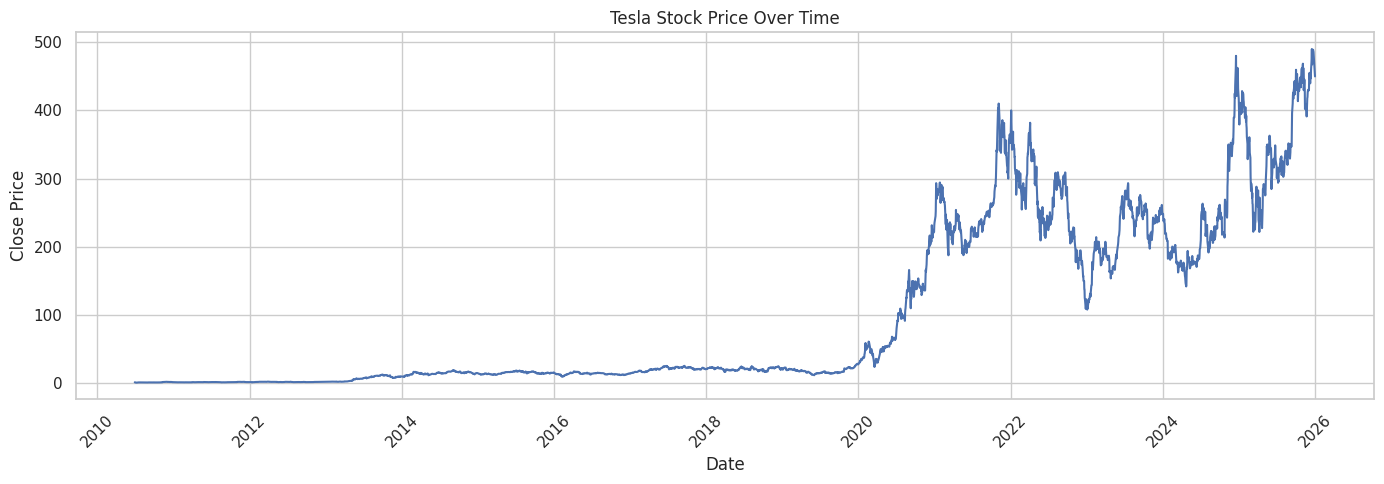

In [66]:
plt.figure(figsize=(14,5))
plt.plot(tesla_df["Date"], tesla_df["Close"])

plt.title("Tesla Stock Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.gca().xaxis.set_major_locator(mdates.YearLocator(2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Distribution of Returns

The distribution of daily returns shows that most price movements are small and centered around zero. However, there are occasional extreme values, indicating periods of high volatility. This highlights the risk associated with Tesla stock and the importance of capturing volatility in the model.

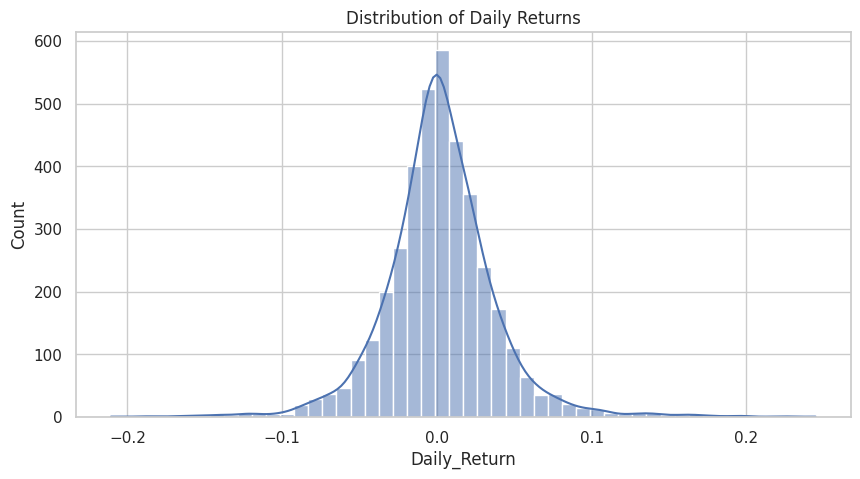

In [67]:
plt.figure(figsize=(10,5))
sns.histplot(tesla_df["Daily_Return"], bins=50, kde=True)
plt.title("Distribution of Daily Returns")
plt.show()

## Correlation Analysis

The correlation heatmap shows strong relationships between price-based features such as moving averages and closing price. These features are likely to be strong predictors in the modeling phase. Volume and volatility also show meaningful variation, suggesting they may contribute additional predictive power.

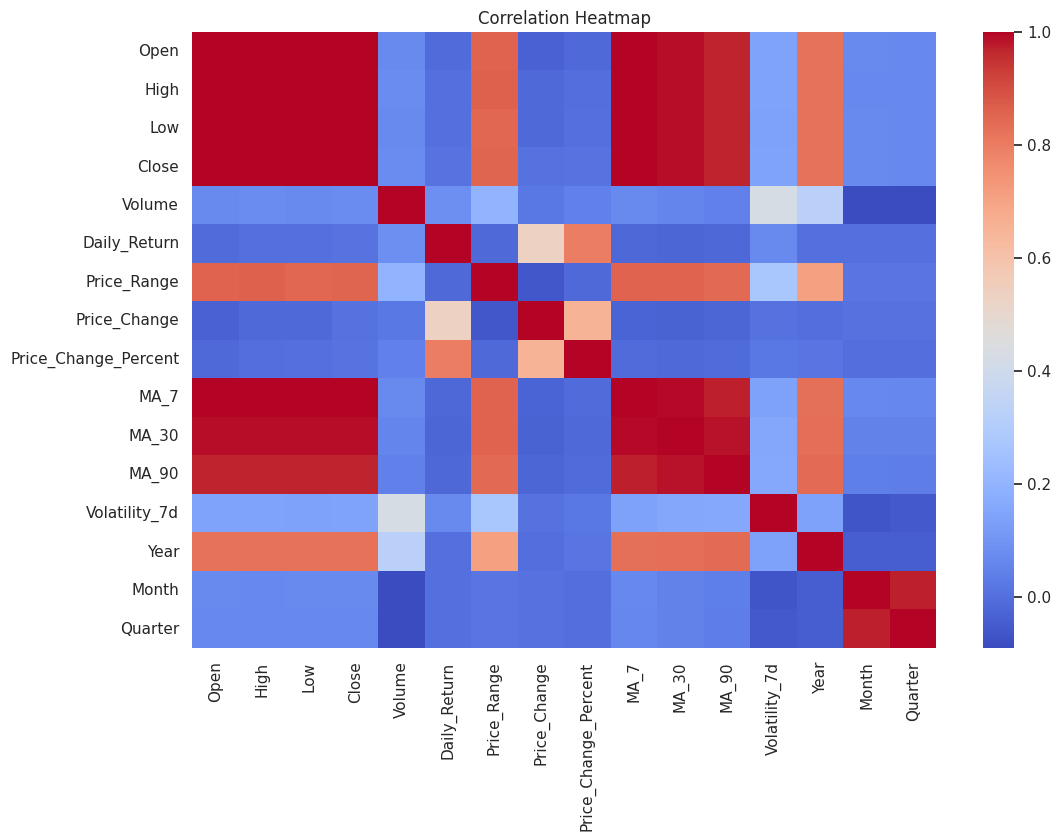

In [68]:
plt.figure(figsize=(12,8))
sns.heatmap(tesla_df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## EV Market Trends

Global EV sales show a strong upward trend over time, reflecting rapid adoption of electric vehicles worldwide. This supports the broader business context that Tesla operates in a growing and competitive market, where external industry trends may influence company performance.

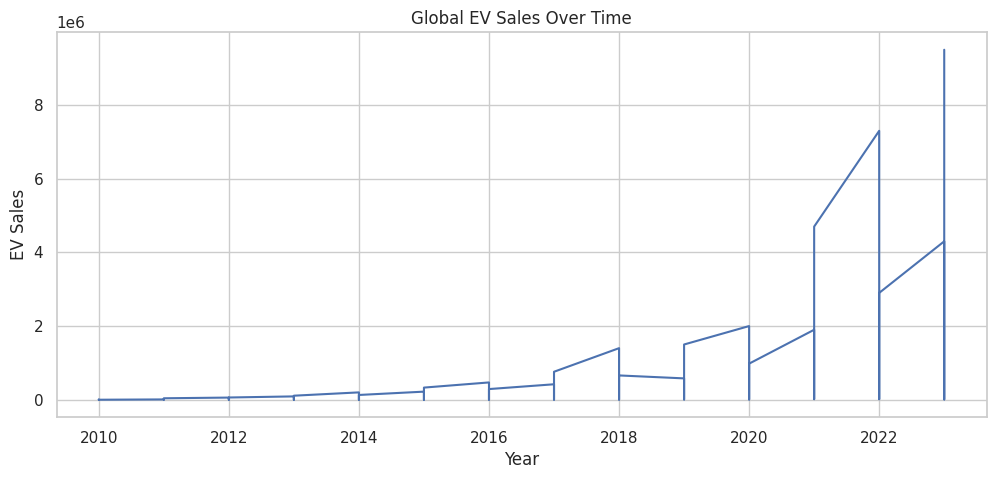

In [69]:
ev_filtered = ev_df[
    (ev_df["region"] == "World") &
    (ev_df["parameter"] == "EV sales") &
    (ev_df["mode"] == "Cars")
]

plt.figure(figsize=(12,5))
plt.plot(ev_filtered["year"], ev_filtered["value"])
plt.title("Global EV Sales Over Time")
plt.xlabel("Year")
plt.ylabel("EV Sales")
plt.show()

## Data Quality & Potential Issues

Several potential data issues were evaluated during the exploration phase.

- Missing Values: The Tesla dataset showed minimal missing values, indicating high data quality. Any missing values introduced later were due to shifting when creating the target variable.
  
- Outliers: The distribution of daily returns and volatility indicates the presence of outliers, particularly during periods of high market activity. These outliers are expected in stock data and represent real market behavior rather than errors.
  
- Inconsistent Formats: The Date column required conversion to datetime format to ensure proper time-series analysis. The EV dataset also required filtering due to its long format structure.

Overall, no major data quality issues were identified that would prevent modeling.

## EDA Summary

The Tesla dataset is clean, structured, and contains sufficient features for predictive modeling. The stock exhibits strong growth with periods of volatility, and several engineered features show strong relationships with price.

The EV dataset provides valuable industry context, demonstrating that Tesla operates within a rapidly expanding market driven by increasing global adoption of electric vehicles.

Overall, the data is well-suited for building machine learning models to predict short-term stock price movements.

# Data Cleaning & Preprocessing

The Tesla dataset was generally well-structured, but several preprocessing steps were required before modeling.

First, the data was sorted chronologically using the Date column to ensure proper time order for time-series analysis. A new target variable, Next_Day_Close, was created by shifting the closing price forward by one day. This represents a realistic prediction problem, where the model uses current information to estimate future stock prices.

Missing Values: The dataset contained minimal missing values. However, missing values were introduced when creating the target variable through the shift operation. These rows were removed to maintain data consistency.

Duplicates: Duplicate rows were checked and removed to ensure each observation represented a unique trading day.

Outliers: Outliers were observed in features such as daily returns and volatility. These were not removed because they reflect real market behavior and are important for capturing stock price fluctuations.

Categorical Encoding: The Day_of_Week feature was converted to a categorical variable and encoded using one-hot encoding to make it suitable for machine learning models.

Scaling: Numerical features were scaled using StandardScaler to ensure consistent magnitude across variables. This is especially important for distance-based models such as K-Nearest Neighbors.

Feature Engineering: The target variable Next_Day_Close was engineered by shifting the closing price. Additional engineered features such as moving averages and volatility were already included in the dataset and used directly in modeling.

These preprocessing steps ensure the dataset is clean, consistent, and ready for machine learning.

In [70]:
# Ensure Date is correct and sorted
tesla_df["Date"] = pd.to_datetime(tesla_df["Date"], errors="coerce")
tesla_df = tesla_df.sort_values("Date").reset_index(drop=True)

In [71]:
# Create target variable
tesla_df["Next_Day_Close"] = tesla_df["Close"].shift(-1)

In [72]:
# Drop rows with missing target
tesla_df = tesla_df.dropna(subset=["Next_Day_Close"]).copy()

In [73]:
# Remove duplicates
tesla_df = tesla_df.drop_duplicates().copy()

In [74]:
# Quick check
print("Remaining rows:", tesla_df.shape)

Remaining rows: (3901, 19)


In [75]:
features = [
    "Open",
    "High",
    "Low",
    "Volume",
    "Daily_Return",
    "Price_Range",
    "Price_Change",
    "Price_Change_Percent",
    "MA_7",
    "MA_30",
    "MA_90",
    "Volatility_7d",
    "Year",
    "Month",
    "Quarter",
    "Day_of_Week"
]

target = "Next_Day_Close"

X = tesla_df[features].copy()
y = tesla_df[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3901, 16)
y shape: (3901,)


In [76]:
X["Day_of_Week"] = X["Day_of_Week"].astype(str)

In [77]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Identify numeric and categorical features
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

Numeric: ['Open', 'High', 'Low', 'Volume', 'Daily_Return', 'Price_Range', 'Price_Change', 'Price_Change_Percent', 'MA_7', 'MA_30', 'MA_90', 'Volatility_7d', 'Year', 'Month', 'Quarter']
Categorical: ['Day_of_Week']


In [78]:
# Scale and impute numeric features
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [79]:
# Encode and impute categorical features
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [80]:
# Combine into one preprocessor
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])
print("Preprocessor ready.")

Preprocessor ready.


## Preprocessing Pipeline Summary

The preprocessing pipeline was built to prepare the dataset for modeling. Fifteen numerical features were imputed using the median and scaled using StandardScaler, while the categorical feature, Day_of_Week, was encoded using one-hot encoding. After preprocessing, the feature matrix expanded from 16 original predictors to 20 transformed features, reflecting the added one-hot encoded day-of-week variables.

# Modeling Approach

This project uses three regression models to predict Tesla’s next-day closing stock price: Linear Regression, Random Forest Regression, and K-Nearest Neighbors (KNN).

Linear Regression serves as a baseline model to understand linear relationships between features and the target variable.

Random Forest is used to capture nonlinear relationships and interactions between features, which are common in financial data.

K-Nearest Neighbors is included as a distance-based model that compares similar observations, making feature scaling important.

The dataset is split into training and testing sets to evaluate model performance on unseen data. Models are compared using Mean Squared Error (MSE) and R².

In [81]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (3120, 16)
X_test: (781, 16)


## Hyperparameter Tuning

Each model was configured with specific settings to improve performance.

Linear Regression has no major hyperparameters to tune, which is one reason it serves as a clean baseline.

Random Forest was tuned using two key parameters. n_estimators=200 sets the number of decision trees in the ensemble, where more trees generally improves stability. max_depth=10 limits how deep each tree can grow, which prevents overfitting to the training data.

KNN was tuned using n_neighbors=5, meaning each prediction is based on the 5 most similar observations in the training set. A lower value makes the model more sensitive to noise, while a higher value smooths predictions but may miss local patterns.

These settings were selected based on common best practices for financial time-series data and represent a balance between model complexity and generalization.

In [86]:
# Summary of final hyperparameter settings
print("Linear Regression: No hyperparameters tuned (baseline model)")
print("Random Forest: n_estimators=200, max_depth=10, random_state=42")
print("KNN: n_neighbors=5")

Linear Regression: No hyperparameters tuned (baseline model)
Random Forest: n_estimators=200, max_depth=10, random_state=42
KNN: n_neighbors=5


## Train-Test Split

The dataset was split into training and testing sets using an 80/20 split. The training set is used to train the models, while the testing set is used to evaluate how well the models perform on unseen data.

## Linear Regression

In [87]:
# Step 1: Import Linear Regression and evaluation metrics
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Step 2: Build pipeline that preprocesses data then fits the model
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),  # scales and encodes features
    ("model", LinearRegression())     # fits a straight line to the data
])

# Step 3: Train the model on the training set
linear_model.fit(X_train, y_train)

# Step 4: Generate predictions on unseen test data
y_pred_linear = linear_model.predict(X_test)

# Step 5: Evaluate performance
linear_mse = mean_squared_error(y_test, y_pred_linear)
linear_r2 = r2_score(y_test, y_pred_linear)
print("Linear Regression MSE:", linear_mse)
print("Linear Regression R2:", linear_r2)

Linear Regression MSE: 32.662235223790596
Linear Regression R2: 0.9978427853015306


## Linear Regression Results

Linear Regression achieved an MSE of 32.66 and an R² of 0.9978, meaning the model explains approximately 99.78% of the variation in Tesla's next-day closing stock price.

This strong performance is expected given the nature of stock data. Price-based features such as moving averages, open, high, and low prices are highly correlated with the next-day closing price over short time horizons. The model is effectively capturing short-term price continuity rather than discovering deep predictive relationships.

While this result is statistically strong, it also reflects the autocorrelated structure of financial time-series data, where today's price is naturally a strong predictor of tomorrow's price. Linear Regression serves as a useful baseline, and its performance will be compared against the nonlinear models to determine whether additional complexity improves prediction accuracy.

## Random Forest

In [88]:
# Step 1: Import Random Forest
from sklearn.ensemble import RandomForestRegressor

# Step 2: Build pipeline with tuned hyperparameters
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),       # same preprocessing as before
    ("model", RandomForestRegressor(
        n_estimators=200,   # number of trees in the forest
        max_depth=10,       # limits tree depth to prevent overfitting
        random_state=42     # ensures reproducible results
    ))
])

# Step 3: Train on training set
rf_model.fit(X_train, y_train)

# Step 4: Predict on test set
y_pred_rf = rf_model.predict(X_test)

# Step 5: Evaluate performance
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)
print("Random Forest MSE:", rf_mse)
print("Random Forest R2:", rf_r2)

Random Forest MSE: 36.774191508779886
Random Forest R2: 0.9975712064436641


## Random Forest Results

Random Forest achieved an MSE of 36.77 and an R² of 0.9976, explaining approximately 99.76% of the variation in Tesla's next-day closing stock price.

While Random Forest is generally well-suited for capturing nonlinear relationships in financial data, its performance in this case was marginally lower than Linear Regression. This suggests that the relationship between the features and next-day closing price is largely linear, and the additional complexity of an ensemble model did not provide a meaningful advantage here. The model still performed very strongly overall and demonstrates that tree-based methods are a viable approach for short-term stock price prediction.

## KNN

In [89]:
# Step 1: Import KNN
from sklearn.neighbors import KNeighborsRegressor

# Step 2: Build pipeline with n_neighbors set to 5
knn_model = Pipeline(steps=[
    ("preprocessor", preprocessor),         # scaling is critical for KNN
    ("model", KNeighborsRegressor(
        n_neighbors=5   # predicts based on 5 most similar observations
    ))
])

# Step 3: Train on training set
knn_model.fit(X_train, y_train)

# Step 4: Predict on test set
y_pred_knn = knn_model.predict(X_test)

# Step 5: Evaluate performance
knn_mse = mean_squared_error(y_test, y_pred_knn)
knn_r2 = r2_score(y_test, y_pred_knn)
print("KNN MSE:", knn_mse)
print("KNN R2:", knn_r2)

KNN MSE: 186.2378075851472
KNN R2: 0.9876997108991253


## KNN Results

KNN achieved an MSE of 186.24 and an R² of 0.9877, explaining approximately 98.77% of the variation in Tesla's next-day closing stock price.

While this is still a strong result in absolute terms, KNN underperformed relative to both Linear Regression and Random Forest. This is consistent with known limitations of distance-based models on high-dimensional financial data, where similarity between observations does not always translate to price similarity. KNN is also more sensitive to the scale and distribution of features, which may have contributed to its higher error.

## Comparison Table

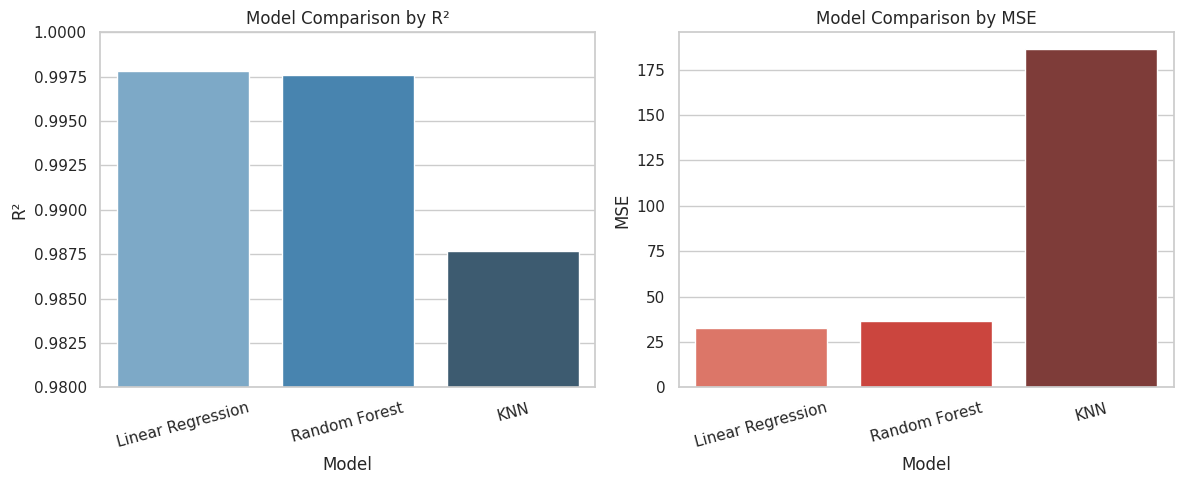

In [85]:
plt.figure(figsize=(12, 5))

ax1 = plt.subplot(1, 2, 1)
sns.barplot(data=results_df, x="Model", y="R2", hue="Model", palette="Blues_d", legend=False)
plt.title("Model Comparison by R²")
plt.ylabel("R²")
plt.ylim(0.98, 1.0)
plt.xticks(rotation=15)

ax2 = plt.subplot(1, 2, 2)
sns.barplot(data=results_df, x="Model", y="MSE", hue="Model", palette="Reds_d", legend=False)
plt.title("Model Comparison by MSE")
plt.ylabel("MSE")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()





## Model Comparison Visualization

The bar charts above provide a visual summary of model performance across both evaluation metrics.

The R² chart shows that Linear Regression and Random Forest performed nearly identically, both explaining over 99.7% of the variation in Tesla's next-day closing price. KNN still achieved a strong R² of 0.9877 but fell noticeably behind the other two models. The y-axis is scaled to begin at 0.98 to make the differences between models visible, as all three results are clustered near the top of the range.

The MSE chart tells the same story more dramatically. Linear Regression and Random Forest both produced low error values of 32.66 and 36.77 respectively, while KNN's MSE of 186.24 stands out clearly. This gap confirms that KNN struggled to match the prediction accuracy of the other two models on this dataset.

Taken together, these visuals reinforce that Linear Regression is the strongest performer for this problem, combining the lowest error with the highest R² and the added benefit of interpretability. Random Forest is a close and competitive alternative, while KNN is better suited to datasets where distance-based similarity is more meaningful than it is in financial time-series data.

# Conclusions & Recommendations

## Best Model

Linear Regression was the best performing model in this project, achieving the lowest MSE of 32.66 and the highest R² of 0.9978. Random Forest performed nearly identically with an R² of 0.9976, confirming that the signal in the data is strong regardless of model complexity. KNN lagged behind both models with an MSE of 186.24, indicating that distance-based similarity is less effective for this type of financial time-series data.

## Business Recommendations

Short-term Tesla stock prices are strongly driven by recent price trends and technical indicators such as moving averages and volatility. Investors and analysts can use a model like this as a supplementary tool for short-term decision support, particularly when combined with fundamental analysis and broader market context.

The global EV market data reinforces that Tesla operates in a rapidly expanding industry. Sustained EV adoption growth provides a supportive macro environment for Tesla's long-term performance, even as short-term stock behavior is driven primarily by technical factors.

## Next Steps

Future analysis could explore the following directions to improve predictive depth:

- Incorporate external variables such as interest rates, sentiment data, or competitor performance
- Test time-series specific models such as LSTM or ARIMA that respect the sequential nature of stock data
- Apply cross-validation instead of a single train/test split to improve evaluation reliability
- Expand the EV dataset integration to test whether global adoption trends have measurable impact on Tesla stock returns

# Final Descriptive Charts

This section presents six charts that summarize the key insights from the analysis. These visuals highlight Tesla stock trends, seasonal patterns, model performance, and prediction accuracy. All charts use consistent formatting for use in the final presentation.

In [90]:
# Set consistent style for all final charts
sns.set_theme(style="whitegrid")
TITLE_SIZE = 14
LABEL_SIZE = 11
COLOR_MAIN = "steelblue"

## Chart 1: Tesla Stock Price with Moving Averages

This chart shows Tesla's closing price alongside the 7, 30, and 90-day moving averages. It highlights the long-term growth trend and periods of volatility that make short-term prediction challenging.

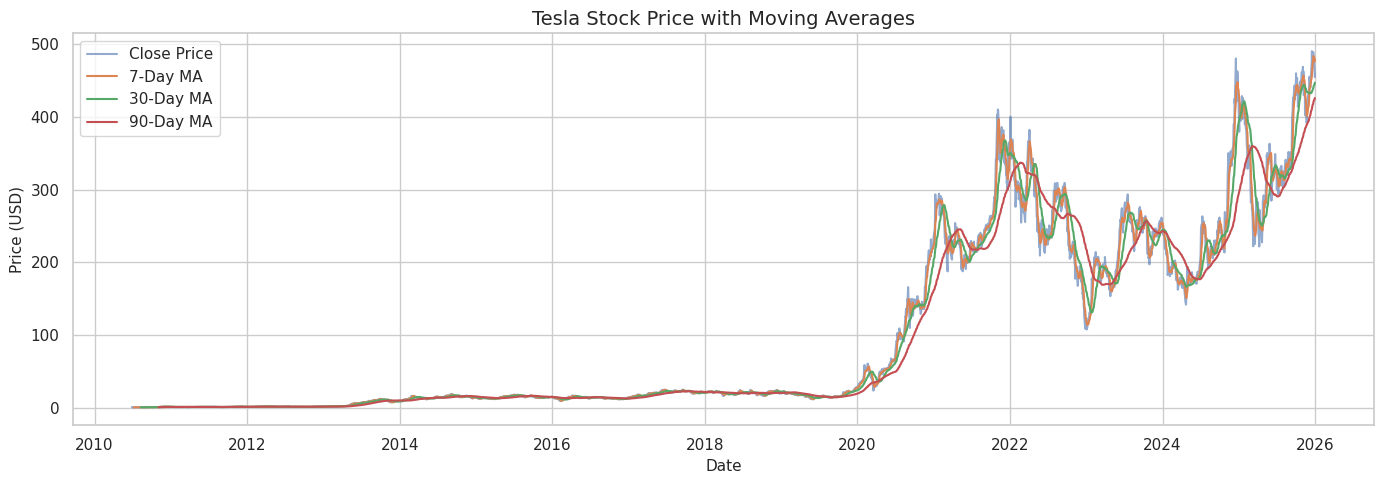

In [91]:
# Chart 1: Tesla closing price with moving averages overlaid
plt.figure(figsize=(14, 5))

plt.plot(tesla_df["Date"], tesla_df["Close"], label="Close Price", alpha=0.6)
plt.plot(tesla_df["Date"], tesla_df["MA_7"], label="7-Day MA", linewidth=1.5)
plt.plot(tesla_df["Date"], tesla_df["MA_30"], label="30-Day MA", linewidth=1.5)
plt.plot(tesla_df["Date"], tesla_df["MA_90"], label="90-Day MA", linewidth=1.5)

plt.title("Tesla Stock Price with Moving Averages", fontsize=TITLE_SIZE)
plt.xlabel("Date", fontsize=LABEL_SIZE)
plt.ylabel("Price (USD)", fontsize=LABEL_SIZE)
plt.legend()
plt.tight_layout()
plt.show()

## Chart 2: Annual Average Closing Price

This chart shows Tesla's average closing price by year, illustrating the long-term growth trajectory of the stock from its IPO in 2010 through 2025.

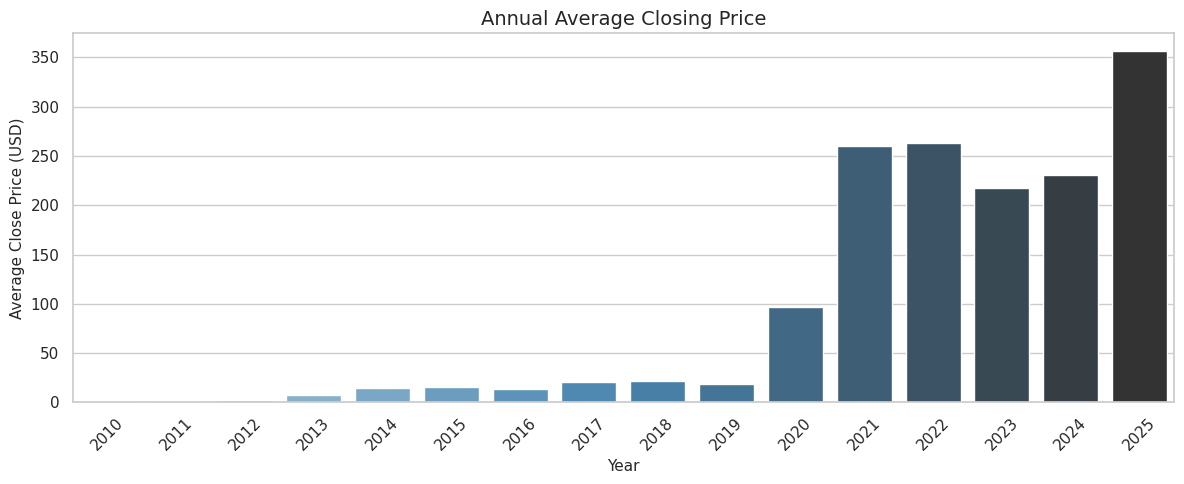

In [92]:
# Chart 2: Calculate and plot average closing price per year
annual_avg = tesla_df.groupby("Year")["Close"].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(data=annual_avg, x="Year", y="Close", hue="Year", palette="Blues_d", legend=False)

plt.title("Annual Average Closing Price", fontsize=TITLE_SIZE)
plt.xlabel("Year", fontsize=LABEL_SIZE)
plt.ylabel("Average Close Price (USD)", fontsize=LABEL_SIZE)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Chart 3: Monthly Average Closing Price (2010-2025)

This chart shows Tesla's average closing price by month, aggregated across the full 15-year dataset from 2010 to 2025. It provides a general sense of whether certain months tend to show stronger or weaker performance on average over the long term.

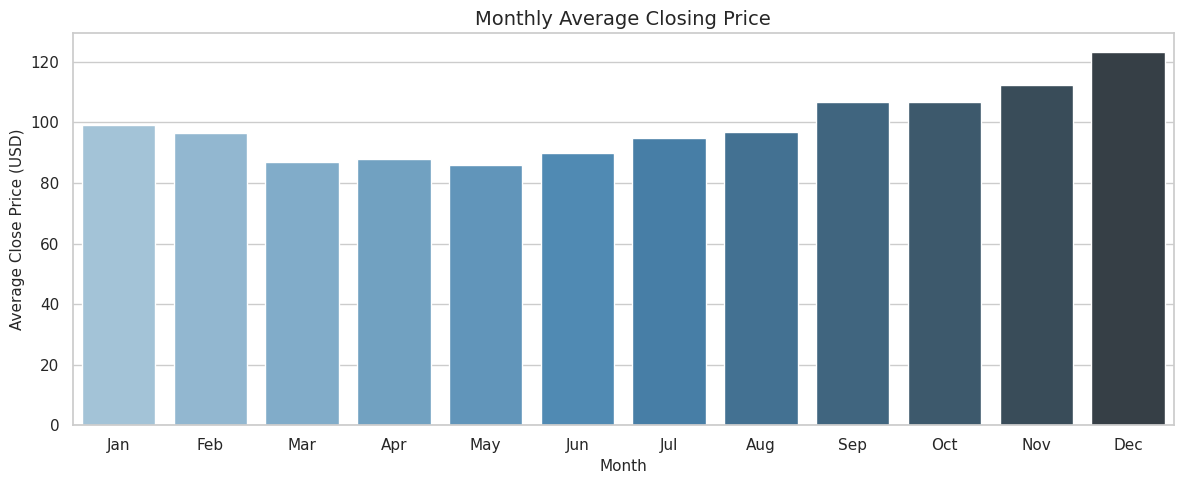

In [93]:
# Chart 3: Calculate and plot average closing price by month
monthly_avg = tesla_df.groupby("Month")["Close"].mean().reset_index()

# Map month numbers to names for readability
month_names = {1:"Jan", 2:"Feb", 3:"Mar", 4:"Apr", 5:"May", 6:"Jun",
               7:"Jul", 8:"Aug", 9:"Sep", 10:"Oct", 11:"Nov", 12:"Dec"}
monthly_avg["Month"] = monthly_avg["Month"].map(month_names)

plt.figure(figsize=(12, 5))
sns.barplot(data=monthly_avg, x="Month", y="Close", hue="Month", palette="Blues_d", legend=False)

plt.title("Monthly Average Closing Price", fontsize=TITLE_SIZE)
plt.xlabel("Month", fontsize=LABEL_SIZE)
plt.ylabel("Average Close Price (USD)", fontsize=LABEL_SIZE)
plt.tight_layout()
plt.show()

## Chart 4: Predicted vs Actual Next Day Close (Linear Regression)

This chart compares the Linear Regression model's predicted next-day closing prices against the actual values from the test set. Points closer to the diagonal line indicate more accurate predictions.

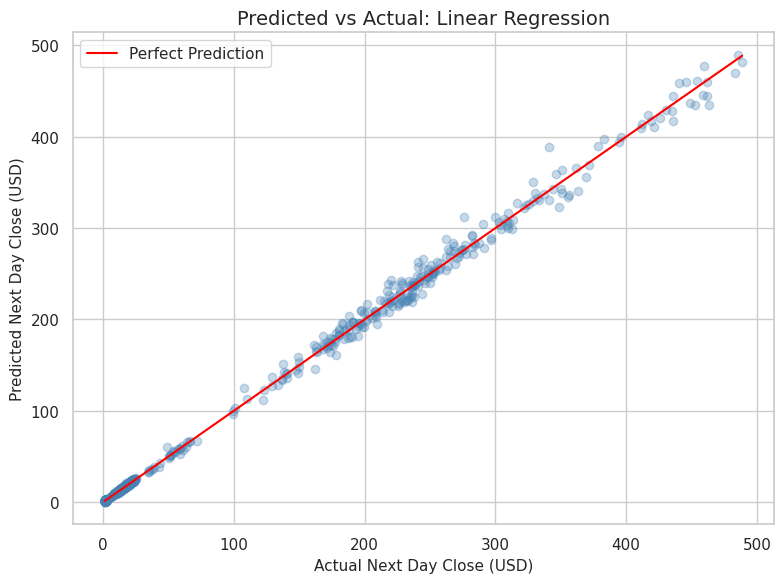

In [94]:
# Chart 4: Scatter plot of predicted vs actual values for Linear Regression
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_linear, alpha=0.3, color=COLOR_MAIN)

# Add a perfect prediction reference line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red", linewidth=1.5, label="Perfect Prediction")

plt.title("Predicted vs Actual: Linear Regression", fontsize=TITLE_SIZE)
plt.xlabel("Actual Next Day Close (USD)", fontsize=LABEL_SIZE)
plt.ylabel("Predicted Next Day Close (USD)", fontsize=LABEL_SIZE)
plt.legend()
plt.tight_layout()
plt.show()

## Chart 5: Model Comparison by R²

This chart compares the R² scores of all three models. A higher R² indicates that the model explains more of the variation in Tesla's next-day closing price.

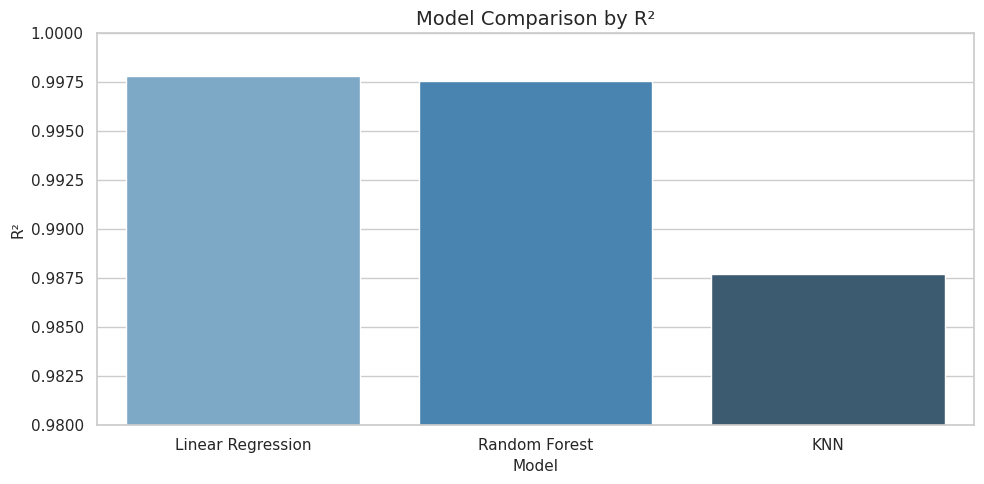

In [95]:
# Chart 5: Bar chart comparing R² scores across all three models
results_df = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "KNN"],
    "MSE": [linear_mse, rf_mse, knn_mse],
    "R2": [linear_r2, rf_r2, knn_r2]
})

plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="Model", y="R2", hue="Model", palette="Blues_d", legend=False)

plt.title("Model Comparison by R²", fontsize=TITLE_SIZE)
plt.xlabel("Model", fontsize=LABEL_SIZE)
plt.ylabel("R²", fontsize=LABEL_SIZE)
plt.ylim(0.98, 1.0)
plt.tight_layout()
plt.show()

## Chart 6: Model Comparison by MSE

This chart compares the Mean Squared Error of all three models. A lower MSE indicates better prediction accuracy. The gap between KNN and the other two models is clearly visible, confirming that Linear Regression and Random Forest outperformed KNN on this dataset.

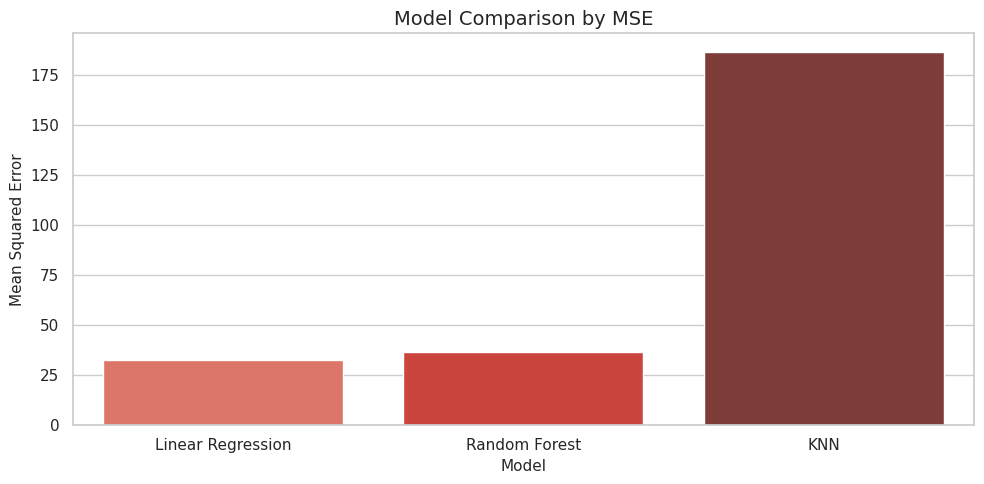

In [96]:
# Chart 6: Bar chart comparing MSE across all three models
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="Model", y="MSE", hue="Model", palette="Reds_d", legend=False)

plt.title("Model Comparison by MSE", fontsize=TITLE_SIZE)
plt.xlabel("Model", fontsize=LABEL_SIZE)
plt.ylabel("Mean Squared Error", fontsize=LABEL_SIZE)
plt.tight_layout()
plt.show()